In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Load MovieLens CSV files into pandas DataFrames
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")

# Display a sample of each dataset
print("Movies:")
display(movies.head())
print("Ratings:")
display(ratings.head())
print("Tags:")
display(tags.head())
print("Links:")
display(links.head())

Movies:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Ratings:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Tags:


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


Links:


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [3]:
# Extract release year from movie titles using regex and convert to float
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

# Drop rows where release year could not be extracted
movies = movies.dropna(subset=['release_year'])
# Remove the year from the title string
movies['title'] = movies['title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()

# Merge movies with links data to get IMDb and TMDb IDs
movies_merged = pd.merge(movies, links, on='movieId')

# Select and rename relevant columns for clarity
movies_clean = movies_merged[['movieId', 'title', 'release_year', 'tmdbId', 'imdbId']].rename(columns={
    'movieId': 'movie_id',
    'tmdbId': 'tmdb_id',
    'imdbId': 'imdb_id'
})
# Preview cleaned movies DataFrame
movies_clean.head()

,movie_id,title,release_year,tmdb_id,imdb_id
0,1,Toy Story,1995.0,862.0,114709
1,2,Jumanji,1995.0,8844.0,113497
2,3,Grumpier Old Men,1995.0,15602.0,113228
3,4,Waiting to Exhale,1995.0,31357.0,114885
4,5,Father of the Bride Part II,1995.0,11862.0,113041


In [5]:
# Import libraries for API requests
import requests
import time

# TMDb API key
api_key = 'bae94ef9264e0d93d245f6804edefe00'

# Define function to fetch budget, revenue, and production company from TMDb API
def fetch_tmdb_financials(tmdb_id, api_key):
    url = f'https://api.themoviedb.org/3/movie/{int(tmdb_id)}?api_key={api_key}'
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        budget = data.get('budget', 0)
        revenue = data.get('revenue', 0)
        companies = data.get('production_companies', [])
        company = companies[0]['name'] if companies else None
        return pd.Series([budget, revenue, revenue - budget, company])
    else:
        return pd.Series([np.nan, np.nan, np.nan, None])

# Use the first 100 movies with valid TMDb IDs sorted by movie_id (for consistency)
sample_movies = movies_clean.dropna(subset=['tmdb_id']).sort_values('movie_id').head(100)
# Apply the financials fetching function to the sample
financials = sample_movies['tmdb_id'].apply(lambda x: fetch_tmdb_financials(x, api_key))
financials.columns = ['budget', 'revenue', 'profit', 'production_company']
# Combine financial data with movie IDs
sample_financials = pd.concat([sample_movies[['movie_id']], financials], axis=1)
# Preview sample financial data
sample_financials.head()

,movie_id,budget,revenue,profit,production_company
0,1,30000000.0,394436586.0,364436586.0,Pixar
1,2,65000000.0,262821940.0,197821940.0,TriStar Pictures
2,3,25000000.0,71500000.0,46500000.0,Lancaster Gate
3,4,16000000.0,81452156.0,65452156.0,20th Century Fox
4,5,0.0,76594107.0,76594107.0,Touchstone Pictures


In [7]:
# Import MySQL connector
import mysql.connector

# Connect to MySQL server
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="@Mu5tache"
)
cursor = conn.cursor()
# Create database if it doesn't already exist
cursor.execute("CREATE DATABASE IF NOT EXISTS movielens_project")
conn.close()

In [9]:
# Import SQLAlchemy to enable pandas to write to MySQL
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# Define connection credentials
username = 'root'
password = '@Mu5tache'
host = '127.0.0.1'
port = 3306
database = 'movielens_project'

# Encode password for URL
encoded_password = quote_plus(password)
# Create engine for MySQL database
engine = create_engine(f'mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}')

In [11]:
# Write cleaned movies data to the database
movies_clean.to_sql(name='movies', con=engine, if_exists='replace', index=False)
# Write ratings and tags data to the database after renaming columns
ratings.rename(columns={'userId': 'user_id', 'movieId': 'movie_id'}).to_sql(
    name='ratings', con=engine, if_exists='replace', index=False)
tags.rename(columns={'userId': 'user_id', 'movieId': 'movie_id'}).to_sql(
    name='tags', con=engine, if_exists='replace', index=False)
# Write financial sample data to the database
sample_financials.to_sql(name='financials', con=engine, if_exists='replace', index=False)

100

In [13]:
# Query and display all tables in the database
query_tables = "SHOW TABLES;"
tables_df = pd.read_sql(query_tables, con=engine)
print("Tables in database:")
display(tables_df)

Tables in database:


,Tables_in_movielens_project
0,financials
1,movies
2,ratings
3,tags


In [15]:
# Display first 5 rows of each table
from IPython.display import display

print("Movies Table:")
display(pd.read_sql("SELECT * FROM movies LIMIT 5;", con=engine))
print("Ratings Table:")
display(pd.read_sql("SELECT * FROM ratings LIMIT 5;", con=engine))
print("Tags Table:")
display(pd.read_sql("SELECT * FROM tags LIMIT 5;", con=engine))
print("Financials Table:")
display(pd.read_sql("SELECT * FROM financials LIMIT 5;", con=engine))

Movies Table:


,movie_id,title,release_year,tmdb_id,imdb_id
0,1,Toy Story,1995.0,862.0,114709
1,2,Jumanji,1995.0,8844.0,113497
2,3,Grumpier Old Men,1995.0,15602.0,113228
3,4,Waiting to Exhale,1995.0,31357.0,114885
4,5,Father of the Bride Part II,1995.0,11862.0,113041


Ratings Table:


,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Tags Table:


,user_id,movie_id,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


Financials Table:


,movie_id,budget,revenue,profit,production_company
0,1,30000000.0,394436586.0,364436586.0,Pixar
1,2,65000000.0,262821940.0,197821940.0,TriStar Pictures
2,3,25000000.0,71500000.0,46500000.0,Lancaster Gate
3,4,16000000.0,81452156.0,65452156.0,20th Century Fox
4,5,0.0,76594107.0,76594107.0,Touchstone Pictures


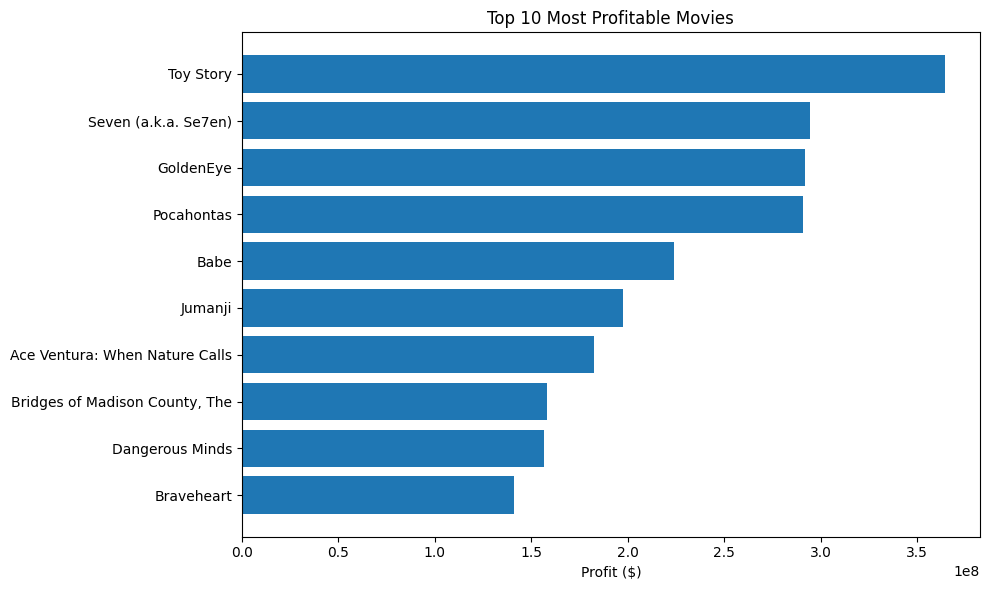

In [17]:
# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Query top 10 most profitable movies
query = """
SELECT m.title, f.profit
FROM financials f
JOIN movies m ON f.movie_id = m.movie_id
ORDER BY f.profit DESC
LIMIT 10;
"""
df = pd.read_sql(query, con=engine)
# Create horizontal bar chart of top 10 most profitable movies
plt.figure(figsize=(10, 6))
plt.barh(df['title'], df['profit'])
plt.xlabel("Profit ($)")
plt.title("Top 10 Most Profitable Movies")
# Highest profit at top
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

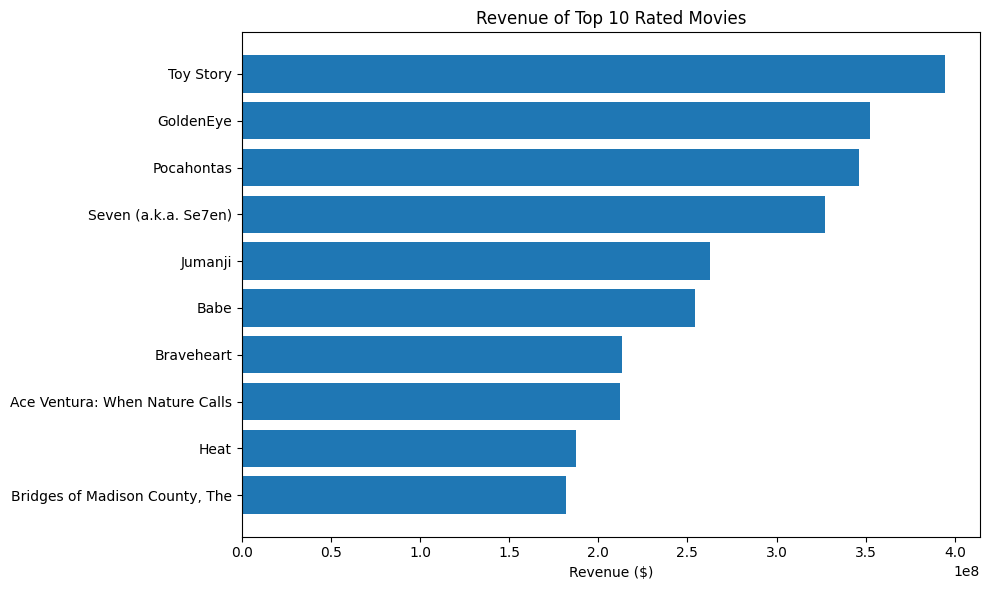

In [19]:
# Query top 10 revenue-generating movies and their average ratings
query = """
SELECT m.title, ROUND(AVG(r.rating), 2) AS avg_rating, f.revenue
FROM ratings r
JOIN movies m ON r.movie_id = m.movie_id
JOIN financials f ON m.movie_id = f.movie_id
GROUP BY m.movie_id, m.title, f.revenue
ORDER BY f.revenue DESC
LIMIT 10;
"""
df_rating_rev = pd.read_sql(query, con=engine)
# Plot top 10 movies by revenue
plt.figure(figsize=(10, 6))
plt.barh(df_rating_rev['title'], df_rating_rev['revenue'])
plt.xlabel("Revenue ($)")
plt.title("Revenue of Top 10 Rated Movies")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

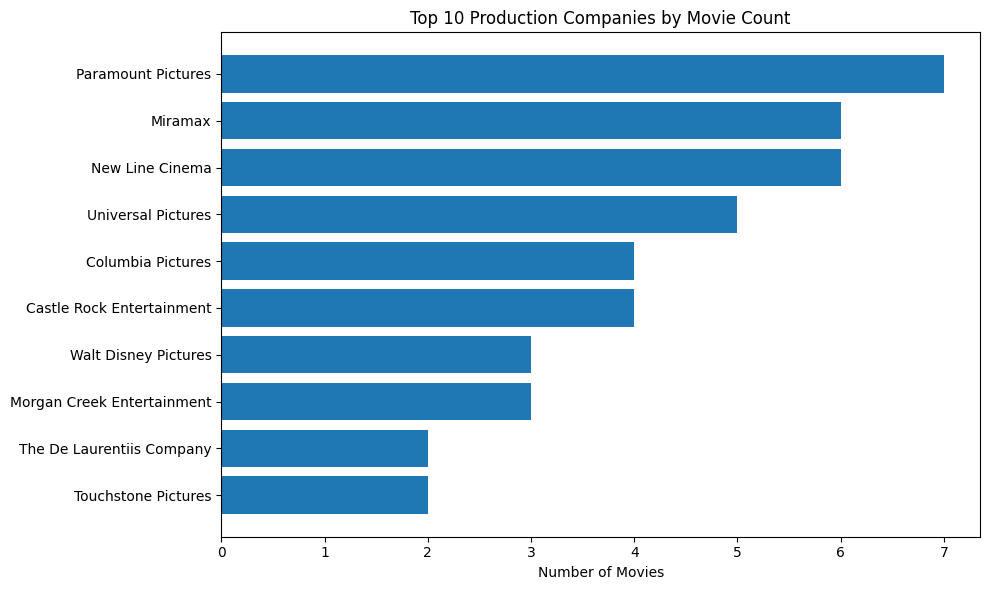

In [21]:
# Query top 10 production companies by number of movies
query = """
SELECT production_company, COUNT(*) AS movie_count
FROM financials
GROUP BY production_company
ORDER BY movie_count DESC
LIMIT 10;
"""
df_companies = pd.read_sql(query, con=engine)
# Remove entries with null production company
df_companies = df_companies.dropna(subset=['production_company'])
# Plot top 10 production companies by movie count
plt.figure(figsize=(10, 6))
plt.barh(df_companies['production_company'], df_companies['movie_count'])
plt.xlabel("Number of Movies")
plt.title("Top 10 Production Companies by Movie Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

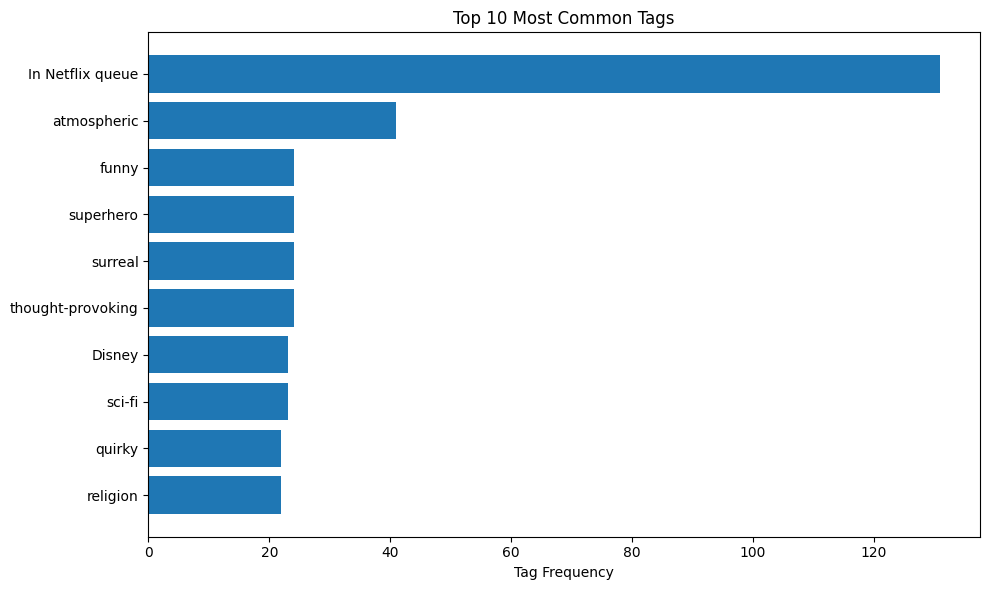

In [23]:
# Query top 10 most frequently used tags
query = """
SELECT tag, COUNT(*) AS frequency
FROM tags
GROUP BY tag
ORDER BY frequency DESC
LIMIT 10;
"""
df_tags = pd.read_sql(query, con=engine)
# Plot top 10 most common tags
plt.figure(figsize=(10, 6))
plt.barh(df_tags['tag'], df_tags['frequency'])
plt.xlabel("Tag Frequency")
plt.title("Top 10 Most Common Tags")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,title,avg_rating,num_ratings
0,Secrets & Lies,4.59,11
1,Guess Who's Coming to Dinner,4.55,11
2,Paths of Glory,4.54,12
3,"Streetcar Named Desire, A",4.47,20
4,"Celebration, The (Festen)",4.46,12
5,"Shawshank Redemption, The",4.43,317
6,Ran,4.43,15
7,His Girl Friday,4.39,14
8,All Quiet on the Western Front,4.35,10
9,Sunset Blvd. (a.k.a. Sunset Boulevard),4.33,27


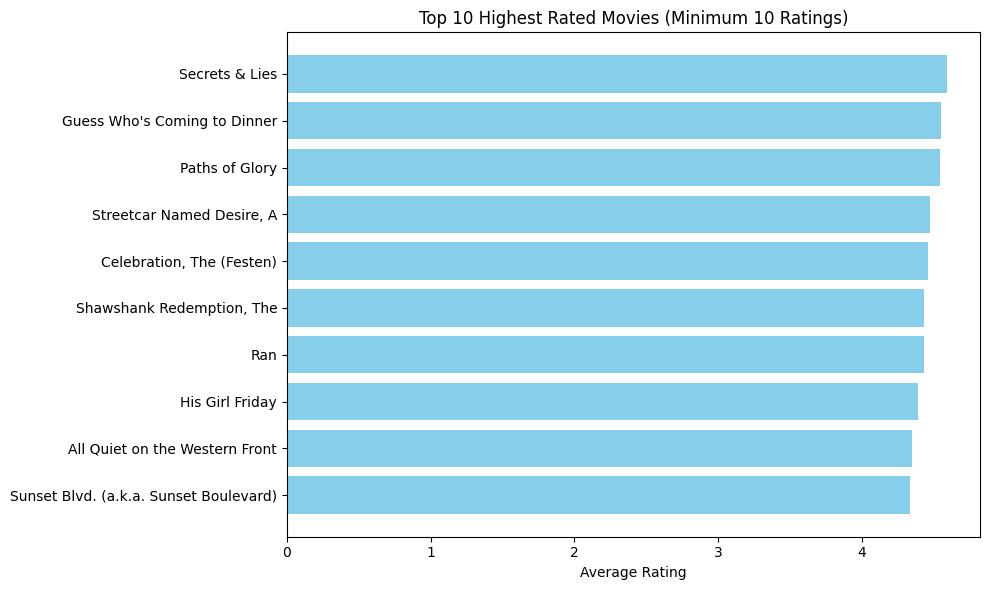

In [25]:
# SQL query to get top 10 highest-rated movies with at least 10 ratings
query = """
SELECT 
    m.title,
    ROUND(AVG(r.rating), 2) AS avg_rating,
    COUNT(*) AS num_ratings
FROM 
    ratings r
JOIN 
    movies m ON r.movie_id = m.movie_id
GROUP BY 
    m.movie_id, m.title
HAVING 
    num_ratings >= 10
ORDER BY 
    avg_rating DESC
LIMIT 10;
"""
# Execute the query
df_top_rated = pd.read_sql(query, con=engine)
# Display the results as a table
display(df_top_rated)
plt.figure(figsize=(10, 6))
plt.barh(df_top_rated['title'], df_top_rated['avg_rating'], color='skyblue')
plt.xlabel("Average Rating")
plt.title("Top 10 Highest Rated Movies (Minimum 10 Ratings)")
plt.gca().invert_yaxis()  # Highest rated at top
plt.tight_layout()
plt.show()